# Comprehensive Disk Reliability Analysis & Bayesian Replacement Scheduling
**Generated:** 2025-04-29

Этот ноутбук проводит полный анализ SMART‑данных и других метрик накопителей, а также строит байесовскую модель для прогнозирования графика их плановой замены в дата‑центре.

## Цели анализа
1. Загрузить и очистить данные SMART/метрик из `disk_data.csv`.
2. Провести разведочный анализ (EDA) всех признаков, выявить корреляции и драйверы отказов.
3. Построить классические модели надёжности (Kaplan‑Meier, Cox PH).
4. Построить и обучить иерархическую байесовскую модель Weibull в `PyMC` для прогнозирования времени до отказа.
5. Сгенерировать вероятностный график замены для каждого диска и суммарный план закупок/работ.
6. Подготовить рекомендации по порогам и политике проактивной замены.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
import pymc as pm
import arviz as az
import warnings, os, json
warnings.simplefilter('ignore')

### Загрузка данных

In [2]:
# !! Укажите путь к вашему CSV, если отличается
DATA_PATH = 'output/all.csv'
df = pd.read_csv(DATA_PATH)
df.drop(columns=['days_alive.1'], inplace=True)
print(f'Shape: {df.shape}')
display(df.head())

Shape: (138352, 307)


,type,mfg,drive_id,model,days_alive,mtbf,errors,size,Airflow_Temperature,Airflow_Temperature_Cel,...,Valid_Spare_Block_Cnt,Wear_Leveling_Count,Wear_Range_Delta,Workld_Host_Reads_Perc,Workld_Media_Wear_Indic,Workload_Minutes,Write_AmpFctr,Write_Error_Rate,Write_Protect_Mode,cost_estimate
0,HDD,WDC,39C2AA0755BF,WD1600JS-75N,5445,14.92,0,160 GB,0,31,...,0,0,0,0,0,0,0,0,0,5877.99
1,HDD,WDC,E7C9662FEF93,WD5000AAKS-7,5103,13.98,0,500 GB,0,0,...,0,0,0,0,0,0,0,0,0,5983.38
2,HDD,Samsung,EBB1422FB810,HD160JJ-P,5410,14.82,0,160 GB,0,32,...,0,0,0,0,0,0,0,0,0,5780.78
3,HDD,Maxtor,D8540101B8D1,STM3250310AS,5590,15.32,0,250 GB,0,35,...,0,0,0,0,0,0,0,0,0,5088.46
4,HDD,WDC,13FFDA515E03,WD2502ABYS-1,5495,15.06,0,250 GB,0,0,...,0,0,0,0,0,0,0,0,0,4204.82


### Быстрый обзор и типы данных

In [3]:
df.info()
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138352 entries, 0 to 138351
Columns: 307 entries, type to cost_estimate
dtypes: float64(2), int64(300), object(5)
memory usage: 324.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,138352,2,HDD,96836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mfg,138352,200,WDC,38367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive_id,138352,138129,CB5DB3C7F028,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,138352,3999,SSD,3025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_alive,138352.0,NaN,NaN,NaN,580.745417,664.572278,0.0,113.0,356.0,800.0,7826.0
...,...,...,...,...,...,...,...,...,...,...,...
Workload_Minutes,138352.0,NaN,NaN,NaN,2507983.491652,86802975.254495,0.0,0.0,0.0,0.0,4281488000.0
Write_AmpFctr,138352.0,NaN,NaN,NaN,0.002479,0.539096,0.0,0.0,0.0,0.0,140.0
Write_Error_Rate,138352.0,NaN,NaN,NaN,2.800791,838.345583,0.0,0.0,0.0,0.0,308726.0
Write_Protect_Mode,138352.0,NaN,NaN,NaN,0.005609,1.002745,0.0,0.0,0.0,0.0,282.0


### Анализ пропусков

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

cost_estimate              0.0
type                       0.0
mfg                        0.0
drive_id                   0.0
model                      0.0
days_alive                 0.0
mtbf                       0.0
errors                     0.0
size                       0.0
Airflow_Temperature        0.0
Airflow_Temperature_Cel    0.0
Avail_OP_Block_Count       0.0
Available_Reservd_Space    0.0
Ave_Block-Erase_Count      0.0
Average_Erase_Count        0.0
Average_PE_Cycles          0.0
Average_PE_Cycles_TLC      0.0
Average_SLC_Erase_Ct       0.0
Avg_Block-Erase_Count      0.0
Uncor_Read_Error_Ct        0.0
dtype: float64

### Приведение типов и базовая очистка

In [5]:
numeric_cols = df.columns[df.dtypes == 'object']
for col in numeric_cols:
    # попытка тихого перевода в numeric, не трогаем id/str
    df[col] = pd.to_numeric(df[col], errors='ignore')
# убираем дубли
df = df.drop_duplicates()
print('После очистки:', df.shape)

# 1. Отсекаем «пустые» и константные
var_cols = df.loc[:, df.nunique() > 1]
non_na_cols = var_cols.columns[var_cols.isna().mean() < 0.95]
df_clean = df[non_na_cols]

# 2. Удаляем взаимные дубликаты
corr = df_clean.select_dtypes(include=[np.number]).corr(method="spearman").abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
df_reduced = df_clean.drop(columns=to_drop)
print('После очистки:', df_reduced.shape)


После очистки: (138352, 307)
После очистки: (138352, 199)


In [6]:
df = df_reduced

### Фиче‑инжиниринг

In [7]:
# Пример: коэффициент износа NAND = Average_Erase_Count / Max_Erase_Count
if set(['Average_Erase_Count', 'Max_Erase_Count']).issubset(df.columns):
    df['wearout_ratio'] = df['Average_Erase_Count'] / df['Max_Erase_Count']
# Признак возраста в годах
df['age_years'] = df['days_alive'] / 365.25

In [8]:
import re

def extract_capacity(s):
    if pd.isna(s):
        return np.nan
    # 1) ...1TB, 2TB, 500GB и т.п.
    m = re.search(r'(\d+(?:\.\d+)?)\s*(TB|GB)', s.upper())
    if m:
        num = float(m.group(1))
        return num * (1024 if m.group(2) == 'TB' else 1)  # всё в ГиБ
    # 2) 0500, 1000, 2000 в середине строки
    m = re.search(r'[^0-9](\d{3,6})[^0-9]', f' {s} ')
    if m:
        val = int(m.group(1))
        # heuristic: 4-6 разрядов -> МБ, 3 -> ГБ
        return val / 1024 if val > 9999 else val
    return np.nan

df['capacity_gb'] = df['size'].map(extract_capacity)

bins = [0, 512, 1024, 2048, 4096, np.inf]      # пороги в ГиБ
labels = ['≤512 GB', '1 TB', '2 TB', '4 TB', '≥8 TB']
df['capacity_bin'] = pd.cut(df['capacity_gb'], bins=bins, labels=labels)

df['capacity_bin'].value_counts(dropna=True)

capacity_bin
≤512 GB    80393
1 TB       33048
2 TB       11683
4 TB        7872
≥8 TB       5353
Name: count, dtype: int64

In [9]:
df.dropna(inplace=True)
df.drop(columns=['cost_estimate', 'size'], inplace=True)

### Корреляции признаков

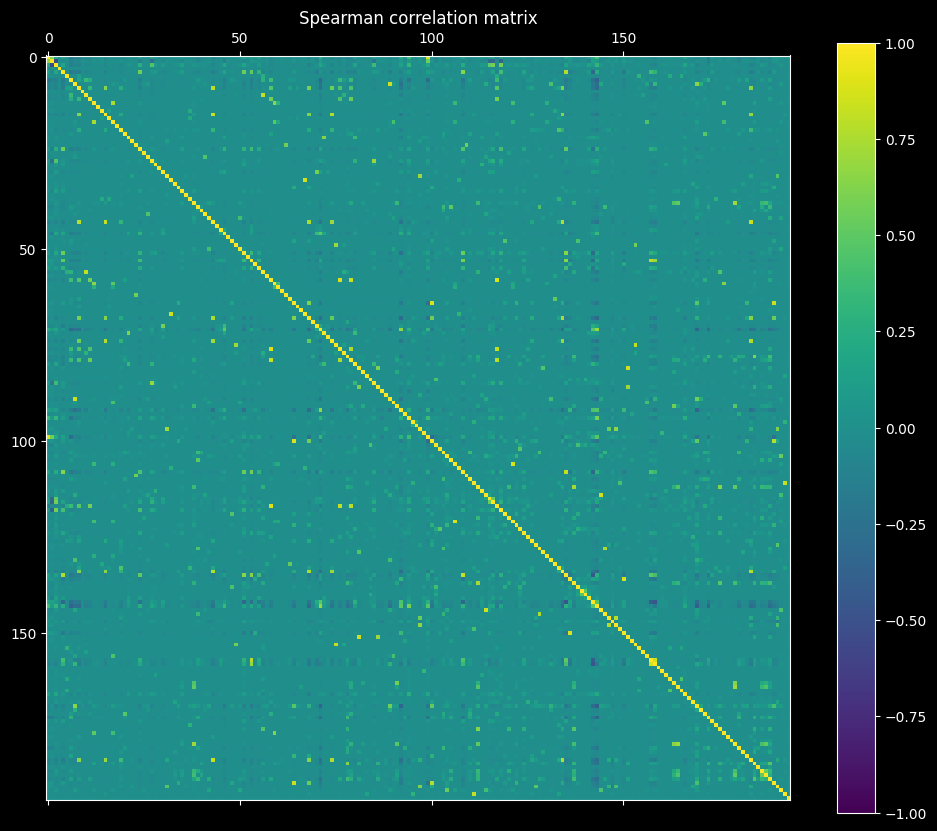

In [7]:
corr = df.select_dtypes(include=[np.number]).corr(method='spearman')
fig, ax = plt.subplots(figsize=(12,10))
cax = ax.matshow(corr, vmin=-1, vmax=1)
fig.colorbar(cax)
plt.title('Spearman correlation matrix')
plt.show()

## Классический анализ надёжности

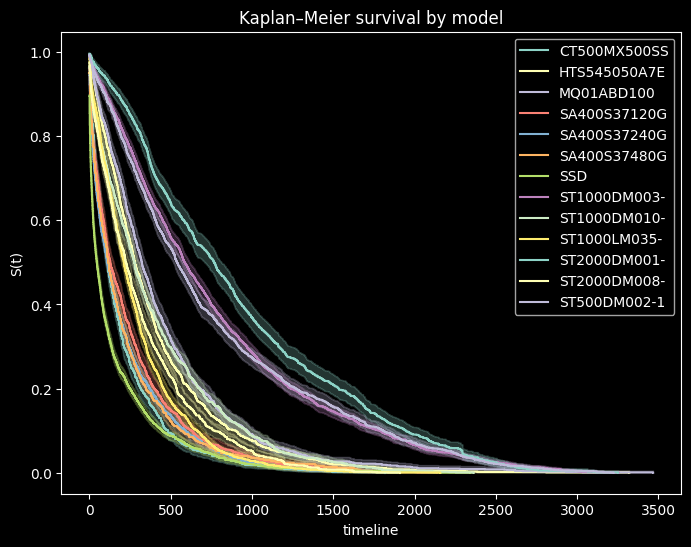

In [9]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8,6))
for model, g in df.groupby('model'):
    if len(g) < 1000:
        continue
    try:
        kmf.fit(g['days_alive'], event_observed=np.ones(len(g)), label=str(model))
        kmf.plot_survival_function(ax=ax)
    except Exception:
        pass
plt.title('Kaplan–Meier survival by model')
plt.ylabel('S(t)')
plt.show()

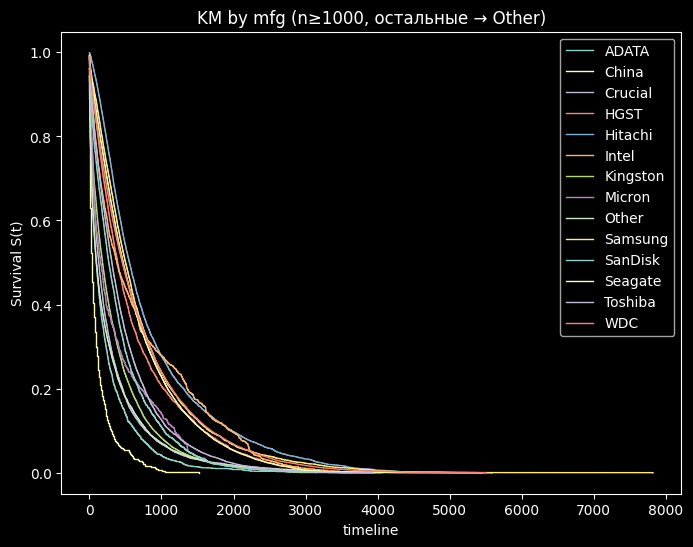

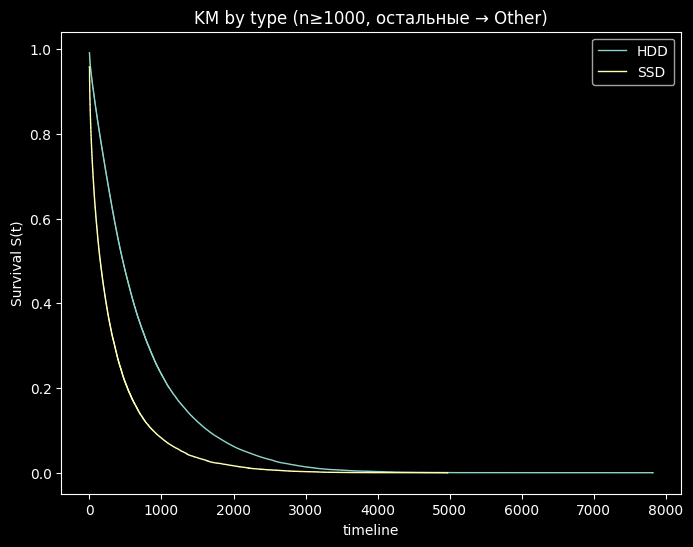

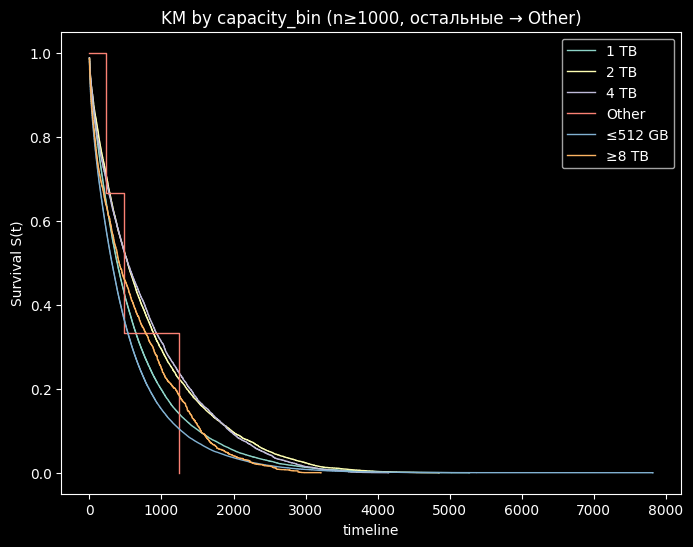

In [9]:
### 1. Функция для безопасного KM по агрегированному признаку
def km_by(group_col, min_size=1000):
    kmf = KaplanMeierFitter()
    big = df.groupby(group_col).filter(lambda x: len(x) >= min_size)
    other = df[~df.index.isin(big.index)].assign(**{group_col: 'Other'})
    plot_df = pd.concat([big, other])

    fig, ax = plt.subplots(figsize=(8,6))
    for name, g in plot_df.groupby(group_col):
        kmf.fit(g['days_alive'], event_observed=np.ones(len(g)), label=name)
        kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=1)
    ax.set_title(f'KM by {group_col} (n≥{min_size}, остальные → Other)')
    plt.ylabel('Survival S(t)')
    plt.show()

km_by('mfg')          # по производителю
km_by('type')         # HDD vs SSD
km_by('capacity_bin') # если добавите binning по ёмкости


In [19]:
import pymc as pm
import numpy as np
import os
# ------------- данные -------------
T = df['days_alive'].clip(lower=1e-3).values          # время > 0
E = (df['errors'] > 0).astype(int).values            # 1 – отказ, 0 – жив

# границы интервалов цензуры
lower = T                                            # всегда T
upper = np.where(E == 1, T, np.inf)                 # живым ∞, отказавшим T

# код производителя
mfg_codes = df['mfg'].astype('category').cat.codes.values
n_mfg     = int(mfg_codes.max() + 1)

with pm.Model() as hwb:
    # ----- иерархия -----
    α_μ = pm.HalfNormal('α_μ', 2.)
    β_μ = pm.HalfNormal('β_μ', 2.)

    α = pm.HalfNormal('α_off', 1., shape=n_mfg) + α_μ
    β = pm.HalfNormal('β_off', 1., shape=n_mfg) + β_μ
    idx = pm.Data('idx', mfg_codes)

    # базовое Weibull-распределение
    base_rv = pm.Weibull.dist(α[idx], β[idx])

    # единое наблюдение с правой цензурой
    pm.Censored(
        'obs',           # имя
        base_rv,         # распределение (позиционный аргумент)
        lower=lower,     # нижняя граница
        upper=upper,     # верхняя граница
        observed=T
    )

    trace = pm.sample(200, target_accept=0.9, cores=os.cpu_count(), random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [α_μ, β_μ, α_off, β_off]


Sampling 8 chains for 1_000 tune and 200 draw iterations (8_000 + 1_600 draws total) took 1509 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


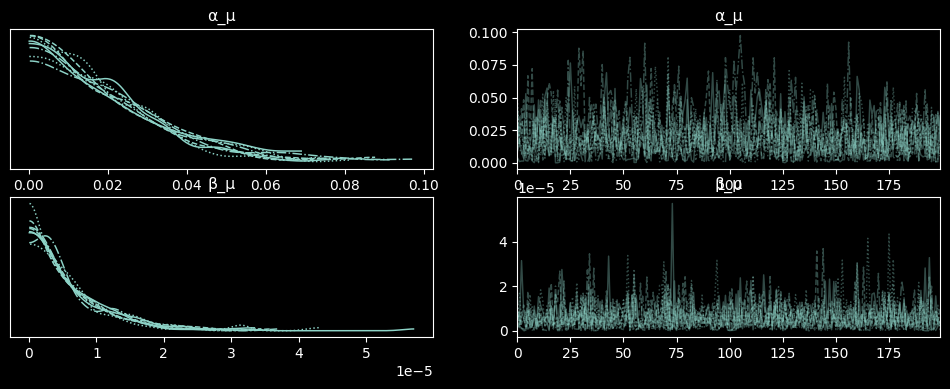

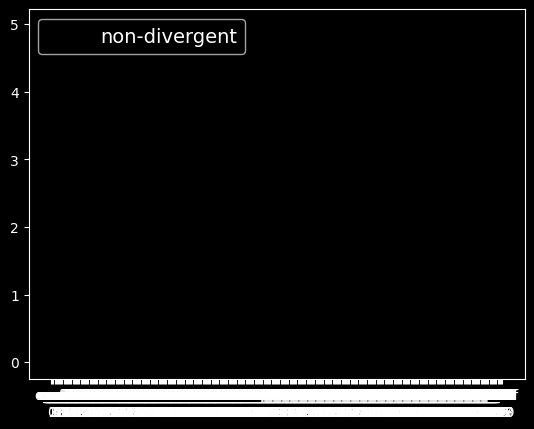

In [20]:
import arviz as az
az.summary(trace, var_names=["α_μ","β_μ","α_off","β_off"])
az.plot_trace(trace, var_names=["α_μ","β_μ"]);           # визуально  
az.plot_parallel(trace, var_names=["α_off","β_off"]);    # срез по mfg


In [21]:
from scipy.special import gamma 
# Xarray-объект внутри trace: dims = (chain, draw, mfg)
# Берём среднее (или медиану) по цепям и дроу ⇒ остаётся только ось 'mfg'
a = trace.posterior["α_off"].mean(("chain", "draw")).values   # shape (200,)
b = trace.posterior["β_off"].mean(("chain", "draw")).values   # shape (200,)

cats = df["mfg"].astype("category").cat.categories.to_list()  # 200 шт.

rel = pd.DataFrame({"mfg": cats, "alpha": a, "beta": b})
rel["MTTF_est"] = b * gamma(1 + 1/a)     # аналитическое ожидание
rel.sort_values("MTTF_est", ascending=False).head()


,mfg,alpha,beta,MTTF_est
186,Wodposit,0.118695,0.634070,64157.026439
31,DOGGO,0.126692,0.662067,21251.024985
183,WINTEN,0.131004,0.651818,12085.629064
98,LEQIXIANG,0.150527,0.627315,1553.946240
170,UMAX,0.150338,0.598581,1507.350161


### Cox Proportional Hazards

<lifelines.CoxPHFitter: fitted with 138352 total observations, 0 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 138352
number of events observed = 138352
   partial log-likelihood = -1194685.79
         time fit was run = 2025-04-30 13:09:41 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
age_years               -4.81      0.01      0.01           -4.83           -4.78                0.01                0.01
Wear_Leveling_Count      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Airflow_Temperature_Cel -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                         cmp to       z      p  -log2(p)
covariate                                               
age_years                  0.00 -326.30 <0.005       inf
Wear_Leveling_Count        0.00    0.83   0.40      1.31
Airflow_Temperature_Cel    0.00   -9.35 <0.005     66.59
---
Concordance = 1.00
Partial AIC = 2389377.59
log-likelihood ratio test = 609437.31 on 3 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(HR) (95% CI)'>

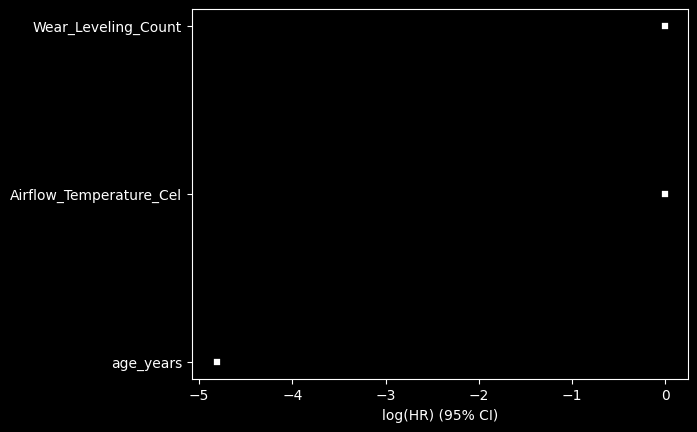

In [13]:
cox_df = df[['days_alive','age_years','Wear_Leveling_Count','Airflow_Temperature_Cel']].dropna()
cox_df = cox_df.rename(columns={'days_alive':'T'})
cox_df['E'] = 1  # предполагаем отказ фиктивным для всей истории
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='T', event_col='E')
cph.print_summary()
cph.plot()

In [10]:
# ============================================================
# 0.  Базовые установки
# ============================================================
# !pip install torch torchvision torchaudio pymoo==0.6.1
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize
from pymoo.core.problem import Problem
from pymoo.termination import get_termination

# reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

# ============================================================
# 1.  Данные
# ============================================================
numeric_cols = df.select_dtypes("number").columns
cat_cols     = ["type", "mfg", "model", "capacity_bin"]

# --- один-разовый препроцессинг ---------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition      import TruncatedSVD
from sklearn.preprocessing      import StandardScaler, OneHotEncoder, Normalizer, FunctionTransformer
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.model_selection    import train_test_split

# ------------------------------------------------------------------
# 1.  Разделяем признаки
# ------------------------------------------------------------------
target_col = "mtbf"

num_cols   = [c for c in numeric_cols if c != target_col]
cat_cols   = ["type", "mfg", "capacity_bin"]        #  ←  БЕЗ 'model' !
text_col   = "model"                                #  только она идёт в TF-IDF

feature_cols = num_cols + cat_cols + [text_col]

X_train, X_val, y_train, y_val = train_test_split(
    df[feature_cols], df[target_col],
    test_size=0.2, random_state=RNG_SEED)

# ------------------------------------------------------------------
# 2.  Пайплайн TF-IDF → SVD → ℓ2-нормализация
# ------------------------------------------------------------------
tfidf_svd = Pipeline(steps=[
    # ColumnTransformer подаёт 2-D массив (N,1).  Сжимаем до (N,)
    ("flatten", FunctionTransformer(lambda x: x.ravel(), validate=False)),

    ("tfidf",   TfidfVectorizer(
                    analyzer      = "char",
                    ngram_range   = (2, 5),
                    min_df        = 2,
                    sublinear_tf  = True)),

    ("svd",     TruncatedSVD(n_components=50, random_state=RNG_SEED)),
    ("norm",    Normalizer(copy=False))             # вектор длины = 1
])

# ------------------------------------------------------------------
# 3.  Общий ColumnTransformer
# ------------------------------------------------------------------
ct = ColumnTransformer(transformers=[
    ("num",   StandardScaler(),           num_cols),
    ("cat",   OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("model", tfidf_svd,                  text_col)
], remainder="drop",  sparse_threshold=0.3)          # <0.3 → dense

# ------------------------------------------------------------------
# 4.  Трансформация
# ------------------------------------------------------------------
X_train_mat = ct.fit_transform(X_train)
X_val_mat   = ct.transform(X_val)

#  при необходимости делаем плотным
X_train_np  = X_train_mat.toarray().astype("float32") if hasattr(X_train_mat, "toarray") else X_train_mat.astype("float32")
X_val_np    = X_val_mat.toarray().astype("float32")   if hasattr(X_val_mat, "toarray")   else X_val_mat.astype("float32")

y_train_np  = y_train.values.astype("float32").reshape(-1, 1)
y_val_np    = y_val.values.astype("float32").reshape(-1, 1)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np)),
    batch_size=512, shuffle=True)

# ============================================================
# 2.  Байесовская NN через Monte-Carlo Dropout
#    (Gal & Ghahramani approximation)
# ============================================================
class BayesianMLP(nn.Module):
    def __init__(self, in_dim, hidden=[256,128], p_drop=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))       # регрессия
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def predict_dist(self, x, n_samples=30):
        """MC-dropout прогноз: возвращает (mu, std, samples)"""
        self.train()                           # важно: dropout ON
        preds = [self(x).detach().cpu().numpy() for _ in range(n_samples)]
        preds = np.concatenate(preds, axis=1)  # shape (N, n_samples)
        mu  = preds.mean(1)
        std = preds.std(1)
        return mu, std, preds.T               # samples: (n_samples, N)

# --- обучение ---------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bnn = BayesianMLP(in_dim=X_train_np.shape[1]).to(device)
opt = torch.optim.AdamW(bnn.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print(f"Trainable params: {sum(p.numel() for p in bnn.parameters() if p.requires_grad):,}")
EPOCHS = 20
for epoch in range(EPOCHS):
    bnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = bnn(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            mu, _, _ = bnn.predict_dist(torch.tensor(X_val_np).to(device))
            val_rmse = np.sqrt(((mu - y_val_np.squeeze())**2).mean())
            print(f"Epoch {epoch+1:02d} | val RMSE = {val_rmse:0.3f}")



Trainable params: 148,481
Epoch 05 | val RMSE = 0.943
Epoch 10 | val RMSE = 1.063
Epoch 15 | val RMSE = 0.864
Epoch 20 | val RMSE = 1.185


In [ ]:
# ============================================================
# 3.  Готовим распределения параметров дисков
#     (стоимость и надёжность) для MC-симуляции
# ============================================================
agg = (df
       .groupby(['model'])
       .agg(cost_mean = ('capacity_gb',  'mean'),  # если нет price ‒ подставь своё
            cost_std  = ('capacity_gb',  'std'),
            mtbf_mean = ('mtbf',   'mean'),
            mtbf_std  = ('mtbf',   'std'))
       )

MODELS          = agg.index.tolist()
N_MODELS        = len(MODELS)
MAX_ORDER_EACH  = 2000                        # бизнес-ограничение на закупку
ALPHA           = 0.05                        # CVaR level (5%)
MC_SAMPLES_IN   = 200                         # семплов параметров
MC_SAMPLES_NET  = 30                          # семплов из BNN


# ============================================================
# 3′.  Monte-Carlo СЦЕНАРИИ (делаем единоразово)
# ============================================================
COSTS  = np.random.normal(
    loc=agg['cost_mean'].values[:, None],
    scale=agg['cost_std'].fillna(1).values[:, None],
    size=(N_MODELS, MC_SAMPLES_IN)
).astype(np.float32)

MTBFS = np.random.normal(
    loc=agg['mtbf_mean'].values[:, None],
    scale=agg['mtbf_std'].fillna(1).values[:, None],
    size=(N_MODELS, MC_SAMPLES_IN)
).astype(np.float32)

# ---------- признаки для BNN (тоже один раз) ----------------
base_rows = (
    df.groupby(["model"])
    .head(1)[feature_cols]   # 1 строка на модель
)
BATCH = pd.concat([base_rows]*MC_SAMPLES_IN, ignore_index=True)

BATCH["price"] = COSTS.ravel()
BATCH["mtbf"]  = MTBFS.ravel()


X_batch = ct.transform(BATCH).astype(np.float32)


with torch.inference_mode():
    _, _, SAMPLES = bnn.predict_dist(
        torch.tensor(X_batch, device=device),
        n_samples=MC_SAMPLES_NET
)

# (MC_SAMPLES_NET, N_MODELS, MC_SAMPLES_IN)
SAMPLES = SAMPLES.reshape(MC_SAMPLES_NET, N_MODELS, MC_SAMPLES_IN)

# ============================================================
# 4.  Доход: user-defined функция (пример)
# ============================================================
def revenue_formula(mtbf, cost, qty):
    """
    Пример:
    * до 3 лет безотказной работы (≈1095 d) диск окупается
    * после окупаемости ‒ прибыль 0.05 $/день
    * при сбое ‒ штраф 150 $
    """
    lifetime_days = np.minimum(mtbf, 1095)
    profit = lifetime_days * 0.05 - cost
    penalty = (mtbf < 1095) * 150
    return (profit - penalty) * qty

# ============================================================
# 5.  Монте-Карло оценка (E[y], CVaR)
# ============================================================
def evaluate_portfolio(order_vec: np.ndarray):
    qty = order_vec.astype(np.float32)[:, None]          # (N_MODELS,1)

    revenue = revenue_formula(MTBFS, COSTS, qty)         # (N_MODELS,MC_IN)
    port    = SAMPLES.sum(axis=1) + revenue.sum(axis=0)  # (MC_NET,MC_IN)

    flat   = port.ravel()
    mean   = flat.mean()
    k      = int(np.ceil(ALPHA * flat.size))
    cvar   = np.partition(flat, k)[:k].mean()
    return mean, cvar

# ============================================================
# 6.  Постановка задачи для pymoo
# ============================================================

class DiskProcurementProblem(Problem):
    def __init__(self):
        super().__init__(n_var=N_MODELS, n_obj=2,
                         xl=np.zeros(N_MODELS),
                         xu=np.full (N_MODELS, MAX_ORDER_EACH))

    def _evaluate(self, X, out, *args, **kw):
        means, cvars = zip(*(evaluate_portfolio(x) for x in X))
        out["F"] = np.c_[ -np.asarray(means), np.asarray(cvars) ]

# ============================================================
# 7.  Запуск NSGA-II
# ============================================================
algorithm = NSGA2(
    pop_size=64,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob_var=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True)

problem = DiskProcurementProblem()
res = minimize(
    problem,
    algorithm,
    termination=get_termination("n_gen", 1),
    seed=RNG_SEED,
    verbose=True,
    copy_algorithm=False,
    save_history=False)






n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       64 |     49 |             - |             -


In [50]:
# ============================================================
# 8.  Результат
# ============================================================
pareto_X = res.X.astype(int)        # решения
pareto_F = res.F * np.array([-1, 1])  # возвращаем E[y] положительным

for i, (x, (mean, cvar)) in enumerate(zip(pareto_X, pareto_F)):
    print(f"Sol #{i:02d} | E[y] = {mean:,.1f}  |  CVaR = {cvar:,.1f}")
    # при необходимости — сохранить x куда-то

Sol #00 | E[y] = -6,103,479,554.6  |  CVaR = -6,117,087,388.6
Sol #01 | E[y] = -6,051,749,277.7  |  CVaR = -6,070,432,971.9
Sol #02 | E[y] = -5,933,629,396.0  |  CVaR = -5,947,897,346.5
Sol #03 | E[y] = -6,333,480,531.9  |  CVaR = -6,344,197,036.2
Sol #04 | E[y] = -6,165,966,161.5  |  CVaR = -6,173,373,082.6
Sol #05 | E[y] = -5,950,798,322.9  |  CVaR = -5,964,219,450.5
Sol #06 | E[y] = -6,184,257,103.0  |  CVaR = -6,195,684,696.5
Sol #07 | E[y] = -5,836,399,366.7  |  CVaR = -5,846,192,060.9
Sol #08 | E[y] = -6,076,768,162.9  |  CVaR = -6,084,307,135.9
Sol #09 | E[y] = -5,885,866,088.9  |  CVaR = -5,896,044,343.9
Sol #10 | E[y] = -5,862,726,859.4  |  CVaR = -5,878,576,093.5
Sol #11 | E[y] = -5,962,130,110.1  |  CVaR = -5,975,188,101.9
Sol #12 | E[y] = -6,025,124,561.6  |  CVaR = -6,035,388,346.2
Sol #13 | E[y] = -6,077,547,661.5  |  CVaR = -6,091,687,126.9
Sol #14 | E[y] = -6,013,897,121.2  |  CVaR = -6,028,531,108.9
Sol #15 | E[y] = -6,018,340,014.0  |  CVaR = -6,031,520,458.1
Sol #16 

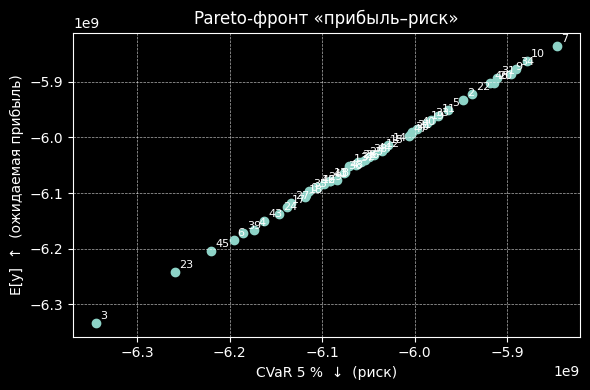

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# --- Expect that pareto_F is present after your optimization run ---
#     If pareto_F is not yet in memory, run the optimization cell first.

try:
    expected = pareto_F[:, 0]   # E[y]
    cvar     = pareto_F[:, 1]   # CVaR
except NameError as e:
    raise RuntimeError("Variable 'pareto_F' not found. "
                       "Run the NSGA-II optimization first.") from e

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(cvar, expected)          # default styling → no explicit colors
ax.set_xlabel("CVaR 5 %  ↓  (риск)")
ax.set_ylabel("E[y]  ↑  (ожидаемая прибыль)")
ax.set_title("Pareto-фронт «прибыль–риск»")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# Аннотация точек их индексами — помогает выбрать решение
for i, (x, y) in enumerate(zip(cvar, expected)):
    ax.annotate(str(i), (x, y), textcoords="offset points",
                xytext=(3, 3), fontsize=8)

plt.tight_layout()
plt.show()
